In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# Cargar dataset
df = pd.read_csv("credit_risk_dataset.csv")

df.head()
df.info()
numeric_columns = df.select_dtypes(include=['int64','float64']).columns

print("Columnas numéricas:")
print(numeric_columns)
# Eliminar valores nulos
df = df.dropna()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB
Columnas numéricas:
Index(['person_age', 'pers

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

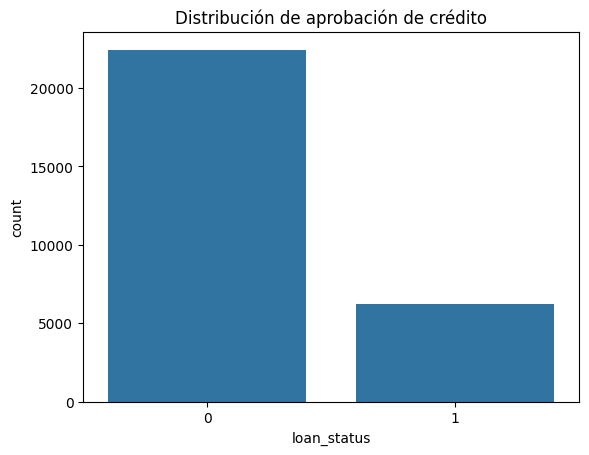

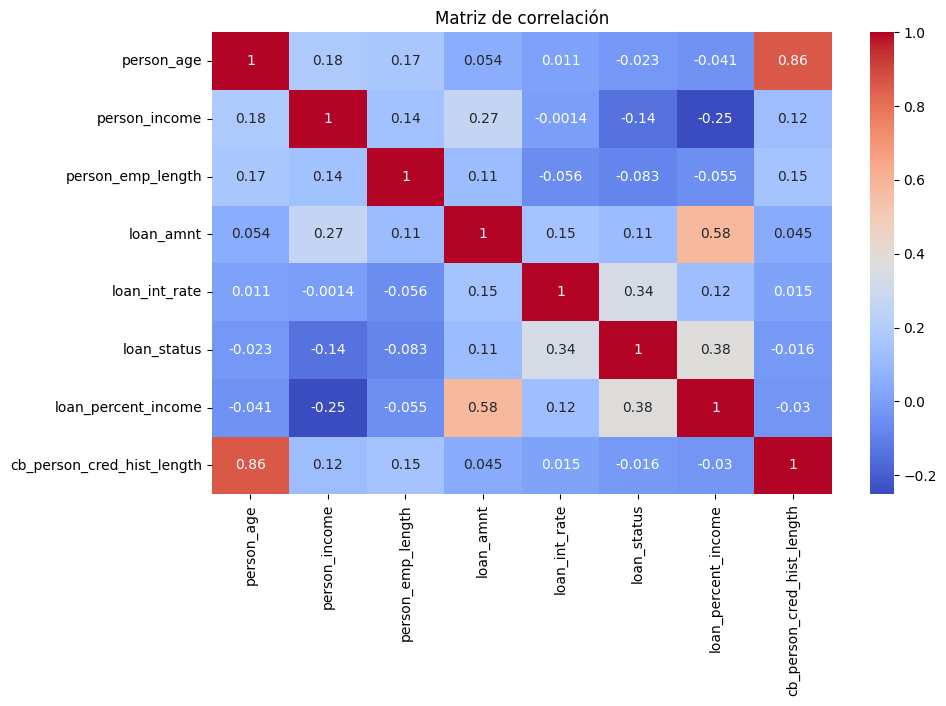

In [19]:
# Estadísticas básicas
df.describe()
sns.countplot(x="loan_status", data=df)
plt.title("Distribución de aprobación de crédito")
plt.show()
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_columns].corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

In [20]:
X = df.select_dtypes(include=['int64', 'float64']).drop('loan_status', axis=1, errors='ignore')
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (22910, 7)
Test: (5728, 7)


In [21]:
model = GaussianNB()

model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [22]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

Accuracy: 0.8072625698324022
              precision    recall  f1-score   support

           0       0.82      0.96      0.89      4443
           1       0.67      0.28      0.40      1285

    accuracy                           0.81      5728
   macro avg       0.74      0.62      0.64      5728
weighted avg       0.79      0.81      0.78      5728



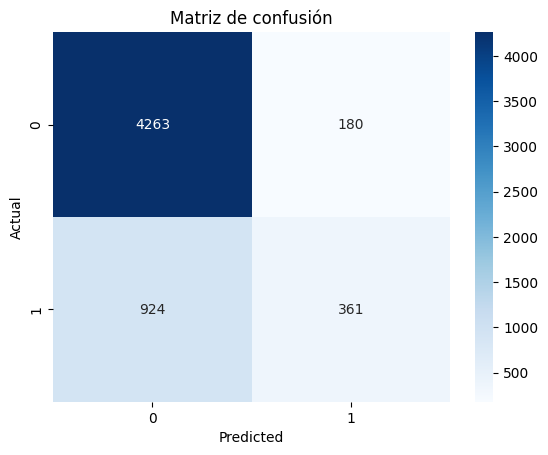

In [23]:
# Calcular el accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()